In [1]:
import pandas as pd
import numpy as np

deliveries = pd.read_csv('data/deliveries.csv')
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [2]:
# Filter inning 2 only
inning2 = deliveries[deliveries['inning'] == 2].copy()
print(inning2.shape)

(125741, 17)


In [3]:
## Engineer In-Match Features
inning2['runs_scored'] = inning2.groupby('match_id')['total_runs'].cumsum()
inning2['wickets_fallen'] = inning2.groupby('match_id')['is_wicket'].cumsum()
inning2['wickets_remaining'] = 10 - inning2['wickets_fallen']
inning2['balls_bowled'] = inning2.groupby('match_id').cumcount() + 1
inning2['overs_bowled'] = inning2['balls_bowled'] / 6

print(inning2[['match_id', 'over', 'ball', 'runs_scored', 'wickets_remaining', 'overs_bowled']].head(10))

     match_id  over  ball  runs_scored  wickets_remaining  overs_bowled
124    335982     0     1            1                 10      0.166667
125    335982     0     2            2                 10      0.333333
126    335982     0     3            2                 10      0.500000
127    335982     0     4            3                 10      0.666667
128    335982     0     5            4                 10      0.833333
129    335982     0     6            4                 10      1.000000
130    335982     0     7            4                 10      1.166667
131    335982     1     1            4                  9      1.333333
132    335982     1     2            4                  9      1.500000
133    335982     1     3            8                  9      1.666667


In [4]:
## Calculate Target from Inning 1
inning1_totals = deliveries[deliveries['inning'] == 1].groupby('match_id')['total_runs'].sum().reset_index()
inning1_totals.columns = ['match_id', 'target']
inning1_totals['target'] = inning1_totals['target'] + 1  # target is always +1 in cricket

inning2 = inning2.merge(inning1_totals, on='match_id', how='left')

# Now calculate runs remaining and required run rate
inning2['runs_remaining'] = inning2['target'] - inning2['runs_scored']
inning2['balls_remaining'] = 120 - inning2['balls_bowled']
inning2['overs_remaining'] = inning2['balls_remaining'] / 6
inning2['crr'] = inning2['runs_scored'] / inning2['overs_bowled']  # current run rate
inning2['rrr'] = inning2['runs_remaining'] / inning2['overs_remaining']  # required run rate

print(inning2[['match_id', 'runs_scored', 'target', 'runs_remaining', 'crr', 'rrr']].head(10))

   match_id  runs_scored  target  runs_remaining       crr        rrr
0    335982            1     223             222  6.000000  11.193277
1    335982            2     223             221  6.000000  11.237288
2    335982            2     223             221  4.000000  11.333333
3    335982            3     223             220  4.500000  11.379310
4    335982            4     223             219  4.800000  11.426087
5    335982            4     223             219  4.000000  11.526316
6    335982            4     223             219  3.428571  11.628319
7    335982            4     223             219  3.000000  11.732143
8    335982            4     223             219  2.666667  11.837838
9    335982            8     223             215  4.800000  11.727273


In [5]:
## Merge with Matches to get Winner
matches = pd.read_csv('data/matches.csv')

# Keep only match_id and winner from matches
match_winners = matches[['id', 'winner']].rename(columns={'id': 'match_id'})

# Merge
inning2 = inning2.merge(match_winners, on='match_id', how='left')

# Drop rows where winner is null (no result matches)
inning2 = inning2.dropna(subset=['winner'])

print(inning2.shape)
print(inning2[['match_id', 'batting_team', 'bowling_team', 'runs_scored', 'target', 'winner']].head())

(125714, 29)
   match_id                 batting_team           bowling_team  runs_scored  \
0    335982  Royal Challengers Bangalore  Kolkata Knight Riders            1   
1    335982  Royal Challengers Bangalore  Kolkata Knight Riders            2   
2    335982  Royal Challengers Bangalore  Kolkata Knight Riders            2   
3    335982  Royal Challengers Bangalore  Kolkata Knight Riders            3   
4    335982  Royal Challengers Bangalore  Kolkata Knight Riders            4   

   target                 winner  
0     223  Kolkata Knight Riders  
1     223  Kolkata Knight Riders  
2     223  Kolkata Knight Riders  
3     223  Kolkata Knight Riders  
4     223  Kolkata Knight Riders  


In [6]:
## Clean Team Names
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

inning2['batting_team'] = inning2['batting_team'].replace(team_name_map)
inning2['bowling_team'] = inning2['bowling_team'].replace(team_name_map)
inning2['winner'] = inning2['winner'].replace(team_name_map)

print(inning2['batting_team'].unique())

['Royal Challengers Bengaluru' 'Punjab Kings' 'Delhi Capitals'
 'Kolkata Knight Riders' 'Rajasthan Royals' 'Mumbai Indians'
 'Chennai Super Kings' 'Deccan Chargers' 'Pune Warriors'
 'Kochi Tuskers Kerala' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Gujarat Lions' 'Gujarat Titans' 'Lucknow Super Giants']


In [7]:
## Create Target Variable
inning2['batting_team_won'] = (inning2['batting_team'] == inning2['winner']).astype(int)

print(inning2['batting_team_won'].value_counts())

batting_team_won
1    65346
0    60368
Name: count, dtype: int64


In [8]:
## Train Model on In-Match Features
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Define features and target
features = ['runs_scored', 'wickets_remaining', 'overs_bowled', 
            'runs_remaining', 'crr', 'rrr', 'target']

# Replace infinite values and nulls caused by division by zero
X = inning2[features].replace([np.inf, -np.inf], 0).fillna(0)
y = inning2['batting_team_won']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.888279043869069


In [9]:
## Train XGBoost Model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_predictions))
print("Random Forest Accuracy: 0.8882")

XGBoost Accuracy: 0.8533985602354532
Random Forest Accuracy: 0.8882


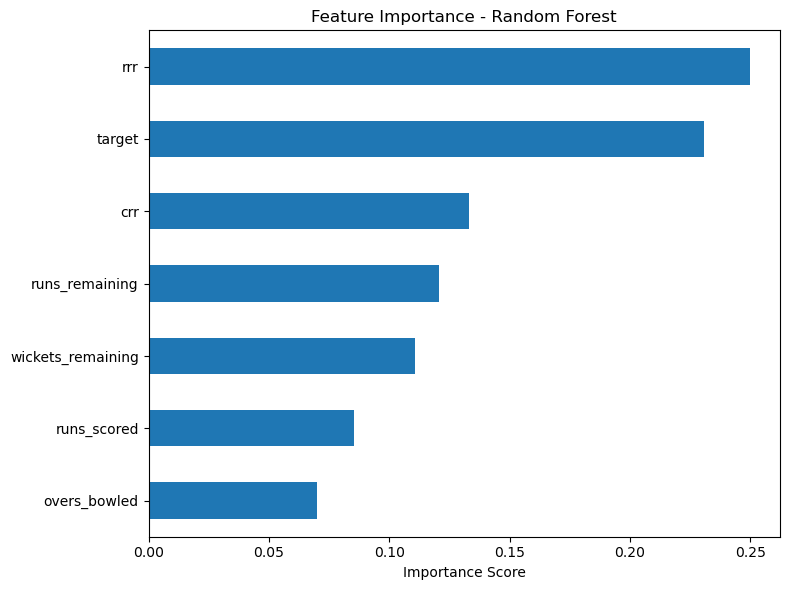

In [10]:
## Feature Importance
import matplotlib.pyplot as plt

feature_importance = pd.Series(model.feature_importances_, index=features)
feature_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [11]:
## Retrain with Team and Venue Features
from sklearn.preprocessing import LabelEncoder

# Add venue from matches
match_venue = matches[['id', 'venue']].rename(columns={'id': 'match_id'})
inning2 = inning2.merge(match_venue, on='match_id', how='left')

# Clean venue names same as before
inning2['venue'] = inning2['venue'].apply(lambda x: x.split(',')[0].strip())
inning2['venue'] = inning2['venue'].replace({'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium'})

le_bat = LabelEncoder()
le_bowl = LabelEncoder()
le_venue = LabelEncoder()

inning2['bat_enc'] = le_bat.fit_transform(inning2['batting_team'])
inning2['bowl_enc'] = le_bowl.fit_transform(inning2['bowling_team'])
inning2['venue_enc'] = le_venue.fit_transform(inning2['venue'])

features_v2 = ['runs_scored', 'wickets_remaining', 'overs_bowled',
               'runs_remaining', 'crr', 'rrr', 'target',
               'bat_enc', 'bowl_enc', 'venue_enc']

X = inning2[features_v2].replace([np.inf, -np.inf], 0).fillna(0)
y = inning2['batting_team_won']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(X_train, y_train)

print("Accuracy v2 (with teams+venue):", accuracy_score(y_test, model_v2.predict(X_test)))
print("Accuracy v1 (without teams+venue): 0.8882")

Accuracy v2 (with teams+venue): 0.9953466173487651
Accuracy v1 (without teams+venue): 0.8882


In [12]:
## Fix Data Leakage - Split by Match ID
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=inning2['match_id']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(X_train, y_train)

print("Accuracy (match-based split):", accuracy_score(y_test, model_v2.predict(X_test)))

Accuracy (match-based split): 0.7782887571100084


In [13]:
## Add More Features
inning2['balls_remaining'] = 120 - (inning2['overs_bowled'] * 6)
inning2['run_rate_diff'] = inning2['crr'] - inning2['rrr']

features_v3 = ['runs_scored', 'wickets_remaining', 'overs_bowled',
               'runs_remaining', 'crr', 'rrr', 'target',
               'bat_enc', 'bowl_enc', 'venue_enc',
               'balls_remaining', 'run_rate_diff']

X = inning2[features_v3].replace([np.inf, -np.inf], 0).fillna(0)
y = inning2['batting_team_won']

train_idx, test_idx = next(gss.split(X, y, groups=inning2['match_id']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model_v3 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v3.fit(X_train, y_train)

print("Accuracy v3 (with extra features):", accuracy_score(y_test, model_v3.predict(X_test)))
print("Accuracy v2 (previous best): 0.7782")

Accuracy v3 (with extra features): 0.7863165113558434
Accuracy v2 (previous best): 0.7782


In [14]:
## Add Momentum Feature
inning2 = inning2.sort_values(['match_id', 'balls_bowled'])
inning2['last_6_balls_runs'] = inning2.groupby('match_id')['total_runs'].transform(
    lambda x: x.rolling(window=6, min_periods=1).sum()
)

features_v4 = ['runs_scored', 'wickets_remaining', 'overs_bowled',
               'runs_remaining', 'crr', 'rrr', 'target',
               'bat_enc', 'bowl_enc', 'venue_enc',
               'balls_remaining', 'run_rate_diff', 'last_6_balls_runs']

X = inning2[features_v4].replace([np.inf, -np.inf], 0).fillna(0)
y = inning2['batting_team_won']

train_idx, test_idx = next(gss.split(X, y, groups=inning2['match_id']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model_v4 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v4.fit(X_train, y_train)

print("Accuracy v4 (with momentum):", accuracy_score(y_test, model_v4.predict(X_test)))
print("Accuracy v3 (previous best): 0.7863")

Accuracy v4 (with momentum): 0.7837750615192223
Accuracy v3 (previous best): 0.7863


In [15]:
## Add Recent Wickets Feature
inning2['last_18_balls_wickets'] = inning2.groupby('match_id')['is_wicket'].transform(
    lambda x: x.rolling(window=18, min_periods=1).sum()
)

features_v5 = ['runs_scored', 'wickets_remaining', 'overs_bowled',
               'runs_remaining', 'crr', 'rrr', 'target',
               'bat_enc', 'bowl_enc', 'venue_enc',
               'balls_remaining', 'run_rate_diff', 'last_18_balls_wickets']

X = inning2[features_v5].replace([np.inf, -np.inf], 0).fillna(0)
y = inning2['batting_team_won']

train_idx, test_idx = next(gss.split(X, y, groups=inning2['match_id']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model_v5 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v5.fit(X_train, y_train)

print("Accuracy v5 (recent wickets):", accuracy_score(y_test, model_v5.predict(X_test)))
print("Accuracy v3 (best so far): 0.7863")

Accuracy v5 (recent wickets): 0.7920448586066401
Accuracy v3 (best so far): 0.7863


In [16]:
## Add Partnership Feature
inning2['runs_since_last_wicket'] = inning2.groupby(['match_id', 'wickets_fallen'])['total_runs'].cumsum()

features_v6 = ['runs_scored', 'wickets_remaining', 'overs_bowled',
               'runs_remaining', 'crr', 'rrr', 'target',
               'bat_enc', 'bowl_enc', 'venue_enc',
               'balls_remaining', 'run_rate_diff', 
               'last_18_balls_wickets', 'runs_since_last_wicket']

X = inning2[features_v6].replace([np.inf, -np.inf], 0).fillna(0)
y = inning2['batting_team_won']

train_idx, test_idx = next(gss.split(X, y, groups=inning2['match_id']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model_v6 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v6.fit(X_train, y_train)

print("Accuracy v6 (partnership):", accuracy_score(y_test, model_v6.predict(X_test)))
print("Accuracy v5 (best so far): 0.7920")

Accuracy v6 (partnership): 0.7903102182419621
Accuracy v5 (best so far): 0.7920


In [17]:
## overfitting/underfitting check for v5
X = inning2[features_v5].replace([np.inf, -np.inf], 0).fillna(0)
y = inning2['batting_team_won']

train_idx, test_idx = next(gss.split(X, y, groups=inning2['match_id']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train accuracy:", accuracy_score(y_train, model_v5.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, model_v5.predict(X_test)))

Train accuracy: 0.999940549913302
Test accuracy: 0.7920448586066401


In [18]:
## Fix Overfitting - Limit Tree Depth
model_v5_fixed = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,        # limit how deep each tree can grow
    min_samples_split=10, # need at least 10 samples to split a node
    random_state=42
)
model_v5_fixed.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, model_v5_fixed.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, model_v5_fixed.predict(X_test)))

Train accuracy: 0.857983651226158
Test accuracy: 0.8106418169349309


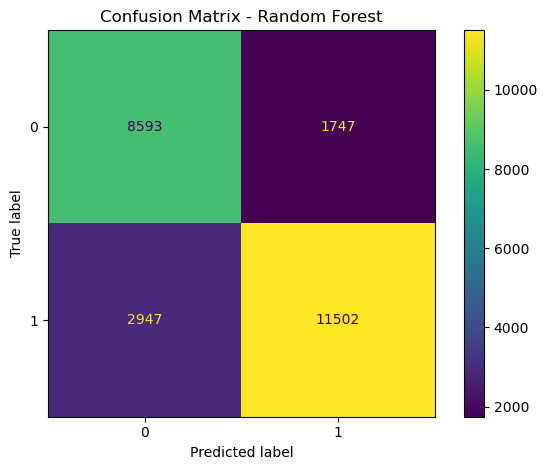

In [19]:
## Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_estimator(model_v5_fixed, X_test, y_test)
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [20]:
## Save Final Model
import pickle
import os

os.makedirs('model', exist_ok=True)

pickle.dump(model_v5_fixed, open('model/rf_model.pkl', 'wb'))
pickle.dump(le_bat, open('model/le_bat.pkl', 'wb'))
pickle.dump(le_bowl, open('model/le_bowl.pkl', 'wb'))
pickle.dump(le_venue, open('model/le_venue.pkl', 'wb'))
pickle.dump(features_v5, open('model/features.pkl', 'wb'))

print("All files saved successfully!")

All files saved successfully!


In [41]:
import os
print(os.listdir('model/'))

['features.pkl', 'le_bat.pkl', 'le_bowl.pkl', 'le_venue.pkl', 'rf_model.pkl']


In [21]:
import pickle
features = pickle.load(open('model/features.pkl', 'rb'))
print(features)

['runs_scored', 'wickets_remaining', 'overs_bowled', 'runs_remaining', 'crr', 'rrr', 'target', 'bat_enc', 'bowl_enc', 'venue_enc', 'balls_remaining', 'run_rate_diff', 'last_18_balls_wickets']
